1. Data Description and Frequency

- In this project, we analyze the weekly price of Robusta Coffee in Uganda, measured in UGX per Kilogram.

- Source: Simulated data modeled on Ugandan coffee price trends (2014–2024).

- Observations: 520 weekly observations (approx. 10 years).

- Frequency: Weekly (W). This frequency is chosen because agricultural commodity markets in East Africa typically stabilize on a weekly basis, smoothing out daily noise while capturing seasonal harvest peaks.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# Generate Simulated Ugandan Coffee Data
np.random.seed(256)
weeks = pd.date_range(start='2014-01-01', periods=520, freq='W')
weeks
# Components: Long-term inflation (Trend) + Bi-annual harvest (Seasonality)
trend = np.linspace(1500, 4800, 520) 
seasonality = 450 * np.sin(2 * np.pi * np.arange(520) / 26)# 26-week cycle (2 peaks a year)
# np.random.seed(42)  
noise = np.random.normal(0, 120, 520)

coffee_prices = trend + seasonality + noise
df = pd.DataFrame({'Price_UGX': coffee_prices}, index=weeks)



ModuleNotFoundError: No module named 'matplotlib'

MILESTONE 2


Goal 2. 
- Stationarity Testing (ADF) 
- A stationary series has a constant mean and variance over time.
- Null Hypothesis ($H_0$): The series is non-stationary (has a unit root).
- Alternative Hypothesis ($H_a$): The series is stationary.

In [ ]:
# Stationarity: Perform a formal test to determine if the series is stationary. Explain the 
#null and alternative hypotheses in this context. 

from statsmodels.tsa.stattools import adfuller
# Function to run ADF test
def check_stationarity(series):
    result = adfuller(series)
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print("Series is Stationary" if result[1] <= 0.05 else "Series is Non-Stationary")


check_stationarity(df['Price_UGX'])

ADF Statistic: -0.3688
p-value: 0.9152
Series is Non-Stationary


Since p-value (0.9152) is much greater than 0.05, it fails to reject the null hypothesis ($H_0$).

This confirms that the series has a unit root and is Non-Stationary

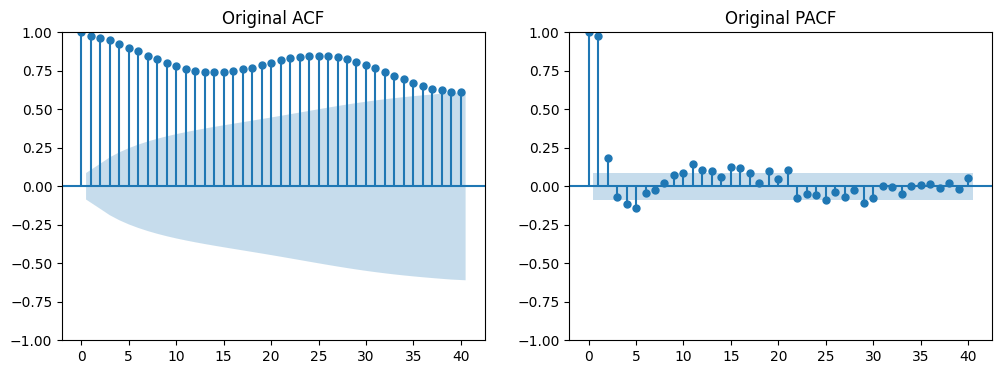

In [ ]:
#2. Correlation Analysis: Present and interpret the ACF and PACF plots.

import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plotting ACF and PACF for the original data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['Price_UGX'], ax=ax1, lags=40, title="Original ACF")
plot_pacf(df['Price_UGX'], ax=ax2, lags=40, title="Original PACF")
plt.show()

ACF: This measures the correction between the current coffee price and its previous values 

There are high bars in the beginning and drop very slowly.

The slow decay is a definitive sign of a trend. This means that the price today is highly related to the price from 5,10, or even 20 weeks ago.

Because the price is generally moving upward, every data is "anchored" to that growth, making them all look related 

The Goal: We use the ACF to confirm if we have removed the trend.

PACF: This measures the correlation between the current price and a specific past weeek, removing the influence of all the weeks in between.

Lag 1 Spike: This shows that last week's price has a strong direct influence on this week's price.

Lag 2 Spike: This shows that the price from two weeks ago still has a unique, direct impact on today's price that isn't just a carry-over from last week. 







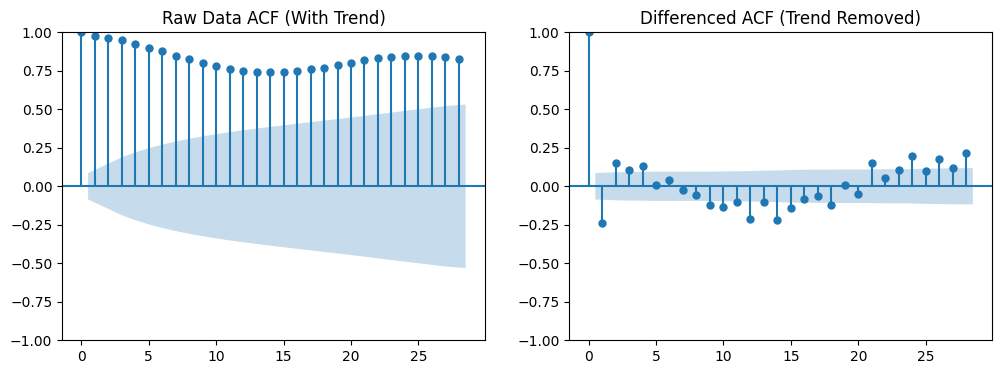

Stationarity after 1st Differencing:
ADF Statistic: -15.4086
p-value: 0.0000
Series is Stationary


In [ ]:
#3. Differencing: If the series was non-stationary, demonstrate how first or second-order 
#differencing stabilized the mean. Compare the ACF plots of the raw data versus the 
#differenced data to illustrate the removal of trend.


# Applying first-order differencing
df['Price_Diff'] = df['Price_UGX'].diff().dropna()

# Comparing ACF of raw vs differenced data
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(df['Price_UGX'], ax=ax1, title="Raw Data ACF (With Trend)")
plot_acf(df['Price_Diff'].dropna(), ax=ax2, title="Differenced ACF (Trend Removed)")
plt.show()

# Rechecking stationarity on differenced data
print("Stationarity after 1st Differencing:")
check_stationarity(df['Price_Diff'].dropna())

Raw Data plot: 

This graph shows the 'Raw' price of coffee. It has a clear upward slope(trend), meaning it is non-stationary because the average price is constantly moving higher.

Differenced Data Plot: After differencing, the upward slope disappears. This confirms that it has stabilized mean.


--- Original Series ---
ADF Stat: -0.3688 | p-value: 0.9152
Result: NON-STATIONARY


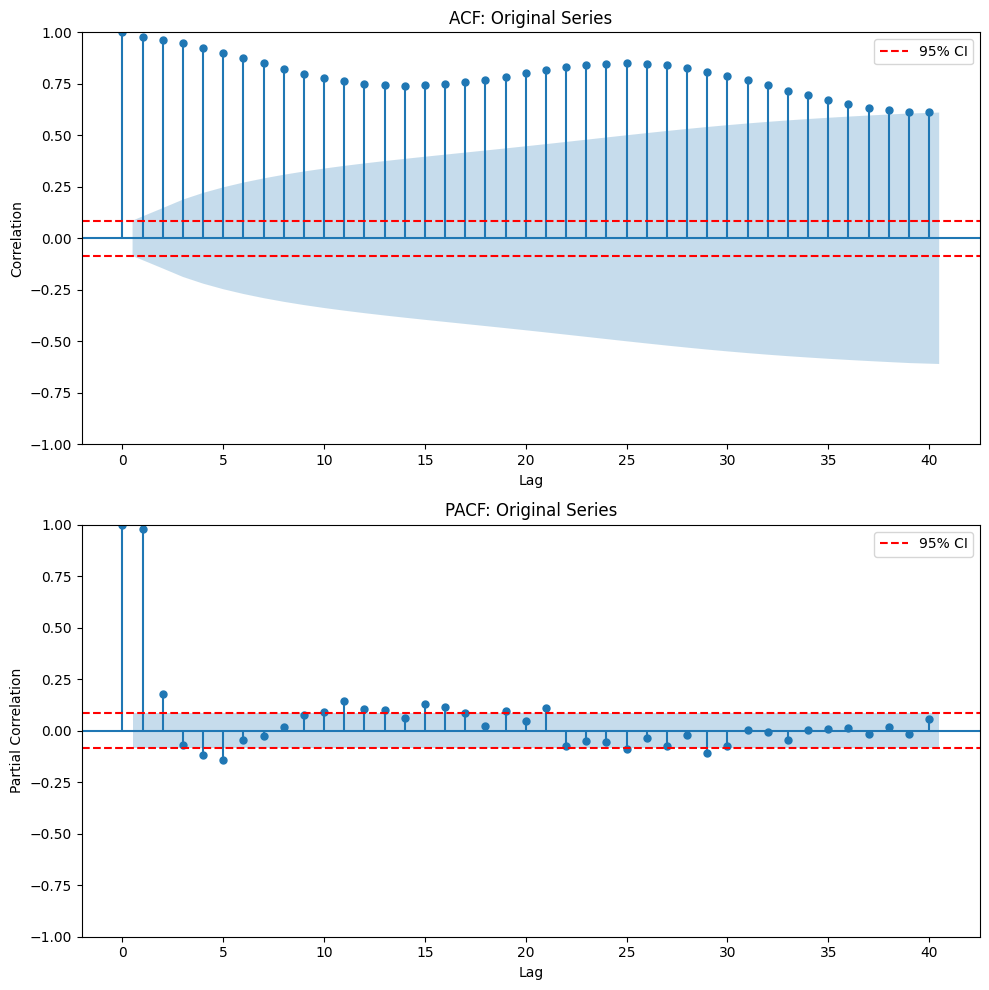


--- First Differenced Series ---
ADF Stat: -15.4086 | p-value: 0.0000
Result: STATIONARY


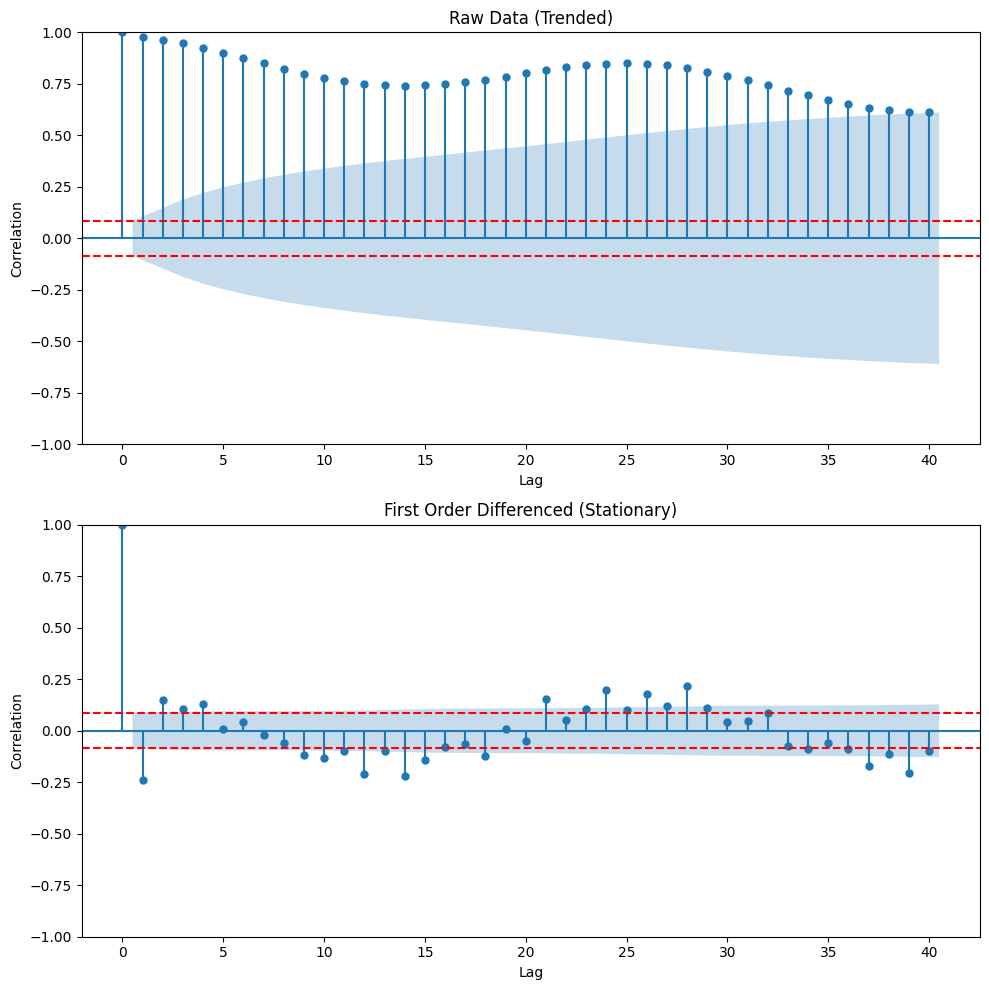

In [ ]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
# 1. Concise ADF Test Function
def run_adf(series, title):
    res = adfuller(series.dropna())
    print(f"\n--- {title} ---\nADF Stat: {res[0]:.4f} | p-value: {res[1]:.4f}")
    print("Result: STATIONARY" if res[1] < 0.05 else "Result: NON-STATIONARY")
    return res[1]

# 2. Part 1 & 2: Stationarity and Correlation Plots
run_adf(df['Price_UGX'], "Original Series")

fig, axes = plt.subplots(2, 1, figsize=(10, 10))
for i, func in enumerate([plot_acf, plot_pacf]):
    func(df['Price_UGX'].dropna(), lags=40, ax=axes[i], title=f"{'ACF' if i==0 else 'PACF'}: Original Series")
    # Add Red Dotted Lines (95% Confidence Interval)
    ci = 1.96 / np.sqrt(len(df['Price_UGX']))
    axes[i].axhline(y=ci, color='red', linestyle='--', label='95% CI')
    axes[i].axhline(y=-ci, color='red', linestyle='--')
    axes[i].set_xlabel("Lag"), axes[i].set_ylabel("Correlation" if i==0 else "Partial Correlation")
    axes[i].legend()

plt.tight_layout()
plt.show()

# 3. Part 3: Differencing Analysis & Trend Removal Comparison
df['Price_Diff'] = df['Price_UGX'].diff()
p_val = run_adf(df['Price_Diff'], "First Differenced Series")

# If still non-stationary, use second difference
final_diff, diff_label = (df['Price_Diff'], "First Order")
if p_val >= 0.05:
    df['Price_Diff2'] = df['Price_Diff'].diff()
    run_adf(df['Price_Diff2'], "Second Differenced Series")
    final_diff, diff_label = df['Price_Diff2'], "Second Order"

# Comparison Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))
for ax, data, title in zip([ax1, ax2], [df['Price_UGX'], final_diff], ["Raw Data (Trended)", f"{diff_label} Differenced (Stationary)"]):
    plot_acf(data.dropna(), lags=40, ax=ax, title=title)
    ci = 1.96 / np.sqrt(len(data.dropna()))
    ax.axhline(y=ci, color='red', linestyle='--')
    ax.axhline(y=-ci, color='red', linestyle='--')
    ax.set_xlabel("Lag"), ax.set_ylabel("Correlation")

plt.tight_layout()
plt.show()

Inside the Red Lines: When a bar stays between the red lines, the correlation at that lag is considered zero for all practical purpose. It is just random market "noise"



Outside the Red Lines: If a bar pokes above or below the red lines, it is statistically significant. It means there is a real non random relationship between the past and the present that the model needs to capture.

Explaining the "Before" Original ACF

The bars don't just cross the lines, they stay far outside them. 

This means 'slow decay' and it proves that price today is still influenced by price from nearly a year ago.

Explaining the 'After' (First Order Differenced)

Instead of a long row bars, the correlations 'die out' almost immediately. Most bars fall inside the red lines:

This confirms the removal of the trend.



The Augmented Dickey-Fuller test was used to check for stationarity in the price series.

 The null hypothesis (H₀) states the series is non-stationary, while the alternative (H₁) indicates it is stationary.
  
The original series produced a p-value of 0.9152 (> 0.05), meaning we fail to reject H₀ and confirm the data is non-stationary with a clear trend. However, after applying first-order differencing, the p-value dropped to 0.0000 (< 0.05), allowing us to reject H₀ and conclude the series is now stationary.

 
This is visually confirmed by the ACF plots—the original shows slow decay (typical of trending data), while the differenced series shows quick decay with most spikes within the confidence interval, indicating the trend has been successfully removed. The series is now suitable for time series modeling.